# EDA Dataset Jumlah Pengangguran Menurut Pendidikan

Notebook ini dibuat untuk eksplorasi awal dataset **Jumlah Pengangguran.csv**.  
Dataset berisi jumlah pengangguran berdasarkan tingkat pendidikan pada periode Februari dan Agustus, dari 2006 sampai 2022.

**Tujuan EDA:**
1. Mengecek struktur data, missing value, duplikasi, dan konsistensi total.
2. Melihat tren total pengangguran dari waktu ke waktu.
3. Membandingkan kontribusi tiap tingkat pendidikan.
4. Menuliskan insight singkat dari hasil eksplorasi.

> Catatan: Jika menjalankan notebook ini di Google Colab, unggah file `Jumlah Pengangguran.csv` terlebih dahulu saat diminta.


In [ ]:
# Import library utama untuk EDA
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pengaturan tampilan angka agar lebih mudah dibaca
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (10, 5)


Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Membaca dataset
# Jika file belum ada di environment Colab, sistem akan meminta upload file CSV.
candidate_paths = [
    'Jumlah Pengangguran.csv',
    '/content/Jumlah Pengangguran.csv',
    '/mnt/data/Jumlah Pengangguran.csv'
]

csv_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if csv_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        csv_path = next(iter(uploaded.keys()))
    except Exception as e:
        raise FileNotFoundError(
            "File CSV belum ditemukan. Silakan upload file 'Jumlah Pengangguran.csv'."
        ) from e

df_raw = pd.read_csv(csv_path)

# Menampilkan 5 baris pertama
display(df_raw.head())

print(f"Lokasi file yang dibaca: {csv_path}")
print(f"Ukuran data awal: {df_raw.shape[0]} baris dan {df_raw.shape[1]} kolom")


,Periode,Bulan,Tidak/belum pernah sekolah,Tidak/belum tamat SD,SD,SLTP,SLTA Umum/SMU,SLTA Kejuruan/SMK,Akademi/Diploma,Universitas,Total
0,2006,Februari,234465,614960,2675459,2860007,2842876,1204140,297185,375601,11104693
1,2006,Agustus,170666,611254,2589699,2730045,2851518,1305190,278074,395554,10932000
2,2007,Februari,145750,520316,2753548,2643062,2630360,1114675,330316,409890,10547917
3,2007,Agustus,94301,438519,2179792,2264198,2532204,1538349,397191,566588,10011142
4,2008,Februari,79764,448431,2216748,2166619,2204377,1165582,519867,626202,9427590


Lokasi file yang dibaca: Jumlah Pengangguran.csv
Ukuran data awal: 35 baris dan 11 kolom


## 1. Struktur awal dataset

In [ ]:
# Mengecek struktur dataset
print("Daftar kolom:")
print(df_raw.columns.tolist())

print("\nTipe data:")
display(df_raw.dtypes.to_frame(name='tipe_data'))

print("\nStatistik deskriptif:")
display(df_raw.describe().T)


Daftar kolom:
['Periode', 'Bulan', 'Tidak/belum pernah sekolah', 'Tidak/belum tamat SD', 'SD', 'SLTP', 'SLTA Umum/SMU', 'SLTA Kejuruan/SMK', 'Akademi/Diploma', 'Universitas', 'Total']

Tipe data:


,tipe_data
Periode,int64
Bulan,object
Tidak/belum pernah sekolah,int64
Tidak/belum tamat SD,int64
SD,int64
SLTP,int64
SLTA Umum/SMU,int64
SLTA Kejuruan/SMK,int64
Akademi/Diploma,int64
Universitas,int64



Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
Periode,35.00,"2,014.23",5.08,"2,006.00","2,010.00","2,014.00","2,018.50","2,022.00"
Tidak/belum pernah sekolah,35.00,"83,398.46","53,949.29","15,206.00","38,596.50","79,764.00","107,820.50","234,465.00"
Tidak/belum tamat SD,35.00,"496,154.71","105,794.40","328,781.00","422,384.00","489,152.00","579,941.00","737,610.00"
SD,35.00,"1,462,738.00","511,294.03","865,778.00","1,219,224.00","1,320,392.00","1,487,256.00","2,753,548.00"
SLTP,35.00,"1,697,167.54","436,737.34","1,137,195.00","1,343,867.00","1,650,387.00","1,828,030.50","2,860,007.00"
SLTA Umum/SMU,35.00,"2,153,685.40","351,845.82","1,546,699.00","1,902,169.00","2,133,627.00","2,437,819.50","2,851,518.00"
SLTA Kejuruan/SMK,35.00,"1,422,717.60","336,165.72","847,365.00","1,184,779.00","1,383,022.00","1,595,546.00","2,326,599.00"
Akademi/Diploma,35.00,"290,182.77","103,575.19","159,490.00","219,345.00","254,457.00","317,788.50","538,186.00"
Universitas,35.00,"642,869.17","167,112.98","375,601.00","548,211.00","626,621.00","743,362.00","999,543.00"
Total,35.00,"8,247,911.91","1,233,931.02","6,898,796.00","7,125,746.50","8,319,779.00","9,032,334.50","11,104,693.00"


## 2. Pemeriksaan kualitas data

In [ ]:
# Mengecek missing value, duplikasi, dan konsistensi Total
missing_values = df_raw.isna().sum().to_frame(name='jumlah_missing')
duplicate_rows = df_raw.duplicated().sum()

edu_cols = [col for col in df_raw.columns if col not in ['Periode', 'Bulan', 'Total']]

df_quality = df_raw.copy()
df_quality['Total_hitung_dari_pendidikan'] = df_quality[edu_cols].sum(axis=1)
df_quality['Selisih_Total'] = df_quality['Total'] - df_quality['Total_hitung_dari_pendidikan']

print(f"Jumlah baris duplikat: {duplicate_rows}")
print(f"Jumlah baris dengan Total tidak sama dengan penjumlahan kategori pendidikan: {(df_quality['Selisih_Total'] != 0).sum()}")

display(missing_values)

# Tampilkan baris yang memiliki selisih total, jika ada
display(df_quality.loc[df_quality['Selisih_Total'] != 0,
                       ['Periode', 'Bulan', 'Total', 'Total_hitung_dari_pendidikan', 'Selisih_Total']])


Jumlah baris duplikat: 1
Jumlah baris dengan Total tidak sama dengan penjumlahan kategori pendidikan: 1


,jumlah_missing
Periode,0
Bulan,0
Tidak/belum pernah sekolah,0
Tidak/belum tamat SD,0
SD,0
SLTP,0
SLTA Umum/SMU,0
SLTA Kejuruan/SMK,0
Akademi/Diploma,0
Universitas,0


,Periode,Bulan,Total,Total_hitung_dari_pendidikan,Selisih_Total
23,2017,Agustus,7005262,7040323,-35061


## 3. Pembersihan sederhana

In [ ]:
# Membersihkan data dasar
# Duplikat dihapus agar periode yang sama tidak terhitung dua kali dalam analisis.
df = df_raw.drop_duplicates().copy()

# Membuat kolom tanggal dari Periode dan Bulan
bulan_map = {'Februari': 2, 'Agustus': 8}
df['Bulan_angka'] = df['Bulan'].map(bulan_map)
df['Tanggal'] = pd.to_datetime(
    df['Periode'].astype(str) + '-' + df['Bulan_angka'].astype(str) + '-01'
)

# Mengurutkan data berdasarkan tanggal
df = df.sort_values('Tanggal').reset_index(drop=True)

print(f"Ukuran data setelah hapus duplikat: {df.shape[0]} baris dan {df.shape[1]} kolom")
display(df[['Tanggal', 'Periode', 'Bulan', 'Total']].head())
display(df[['Tanggal', 'Periode', 'Bulan', 'Total']].tail())


Ukuran data setelah hapus duplikat: 34 baris dan 13 kolom


,Tanggal,Periode,Bulan,Total
0,2006-02-01,2006,Februari,11104693
1,2006-08-01,2006,Agustus,10932000
2,2007-02-01,2007,Februari,10547917
3,2007-08-01,2007,Agustus,10011142
4,2008-02-01,2008,Februari,9427590


,Tanggal,Periode,Bulan,Total
29,2020-08-01,2020,Agustus,9767754
30,2021-02-01,2021,Februari,8746008
31,2021-08-01,2021,Agustus,9102052
32,2022-02-01,2022,Februari,8402153
33,2022-08-01,2022,Agustus,8425931


## 4. Tren total pengangguran

Ringkasan tren total:
- Total awal (Februari 2006): 11,104,693
- Total akhir (Agustus 2022): 8,425,931
- Perubahan total: -2,678,762 orang (-24.12%)
- Total tertinggi: 11,104,693 pada Februari 2006
- Total terendah: 6,898,796 pada Februari 2019


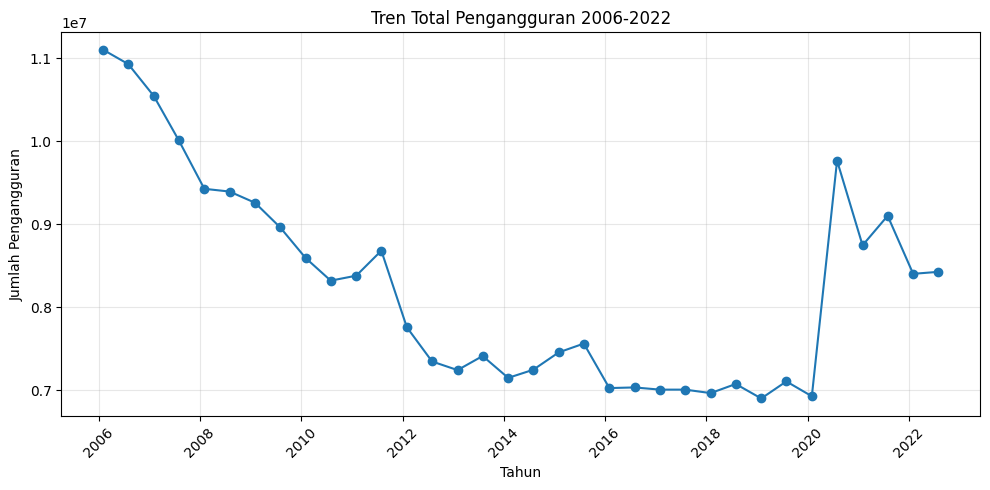

In [ ]:
# Analisis tren total pengangguran
max_row = df.loc[df['Total'].idxmax()]
min_row = df.loc[df['Total'].idxmin()]

awal = df.iloc[0]
akhir = df.iloc[-1]
perubahan_abs = akhir['Total'] - awal['Total']
perubahan_pct = perubahan_abs / awal['Total'] * 100

print("Ringkasan tren total:")
print(f"- Total awal ({awal['Bulan']} {awal['Periode']}): {awal['Total']:,.0f}")
print(f"- Total akhir ({akhir['Bulan']} {akhir['Periode']}): {akhir['Total']:,.0f}")
print(f"- Perubahan total: {perubahan_abs:,.0f} orang ({perubahan_pct:.2f}%)")
print(f"- Total tertinggi: {max_row['Total']:,.0f} pada {max_row['Bulan']} {max_row['Periode']}")
print(f"- Total terendah: {min_row['Total']:,.0f} pada {min_row['Bulan']} {min_row['Periode']}")

# Visualisasi tren total pengangguran
plt.figure()
plt.plot(df['Tanggal'], df['Total'], marker='o')
plt.title('Tren Total Pengangguran 2006-2022')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Pengangguran')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Perbandingan berdasarkan tingkat pendidikan

,rata_rata_jumlah
SLTA Umum/SMU,"2,144,141.65"
SLTP,"1,702,942.85"
SD,"1,468,284.62"
SLTA Kejuruan/SMK,"1,415,694.82"
Universitas,"641,968.71"
Tidak/belum tamat SD,"491,243.82"
Akademi/Diploma,"294,026.68"
Tidak/belum pernah sekolah,"85,404.12"


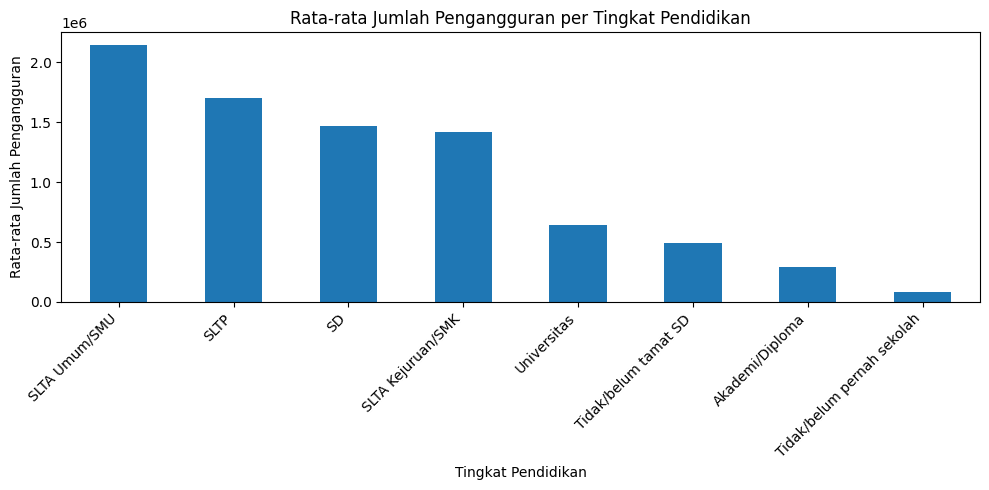

In [ ]:
# Membandingkan rata-rata jumlah pengangguran per tingkat pendidikan
mean_by_edu = df[edu_cols].mean().sort_values(ascending=False)

display(mean_by_edu.to_frame(name='rata_rata_jumlah'))

plt.figure()
mean_by_edu.plot(kind='bar')
plt.title('Rata-rata Jumlah Pengangguran per Tingkat Pendidikan')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Rata-rata Jumlah Pengangguran')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 6. Kontribusi kategori pada periode terakhir

,persentase_periode_terakhir
SLTA Umum/SMU,29.41
SLTA Kejuruan/SMK,19.72
SLTP,17.81
SD,15.12
Universitas,7.99
Tidak/belum tamat SD,7.87
Akademi/Diploma,1.89
Tidak/belum pernah sekolah,0.18


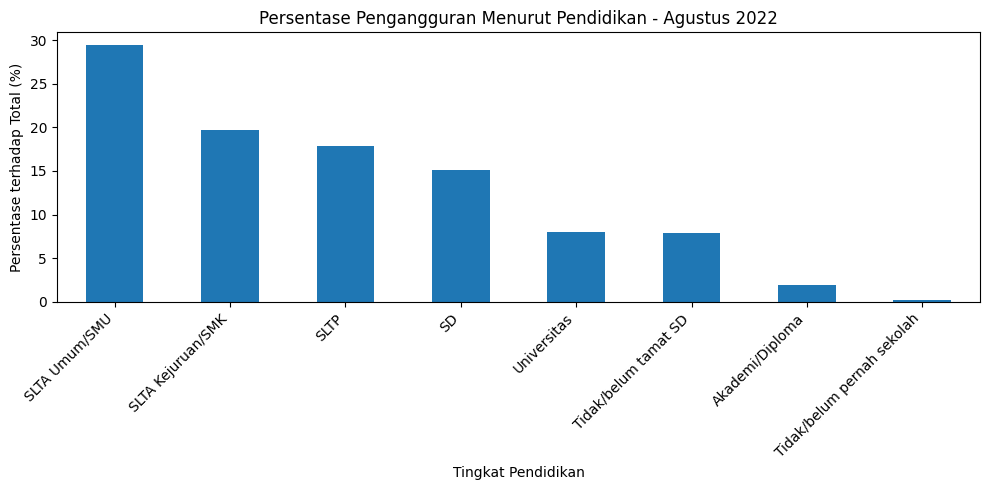

In [ ]:
# Melihat kontribusi setiap tingkat pendidikan pada periode terakhir
latest = df.iloc[-1]
latest_share = (latest[edu_cols] / latest['Total'] * 100).sort_values(ascending=False)

display(latest_share.to_frame(name='persentase_periode_terakhir'))

plt.figure()
latest_share.plot(kind='bar')
plt.title(f'Persentase Pengangguran Menurut Pendidikan - {latest["Bulan"]} {latest["Periode"]}')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Persentase terhadap Total (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. Perubahan year-on-year

,Tanggal,Bulan,Periode,Total,Perubahan_YoY,Perubahan_YoY_%
24,2018-02-01,Februari,2018,6963457,"-41,805.00",-0.60
25,2018-08-01,Agustus,2018,7073385,"68,123.00",0.97
26,2019-02-01,Februari,2019,6898796,"-64,661.00",-0.93
27,2019-08-01,Agustus,2019,7104424,"31,039.00",0.44
28,2020-02-01,Februari,2020,6925486,"26,690.00",0.39
29,2020-08-01,Agustus,2020,9767754,"2,663,330.00",37.49
30,2021-02-01,Februari,2021,8746008,"1,820,522.00",26.29
31,2021-08-01,Agustus,2021,9102052,"-665,702.00",-6.82
32,2022-02-01,Februari,2022,8402153,"-343,855.00",-3.93
33,2022-08-01,Agustus,2022,8425931,"-676,121.00",-7.43


Kenaikan YoY terbesar terjadi pada Agustus 2020: naik 2,663,330 orang atau 37.49% dibanding bulan yang sama tahun sebelumnya.


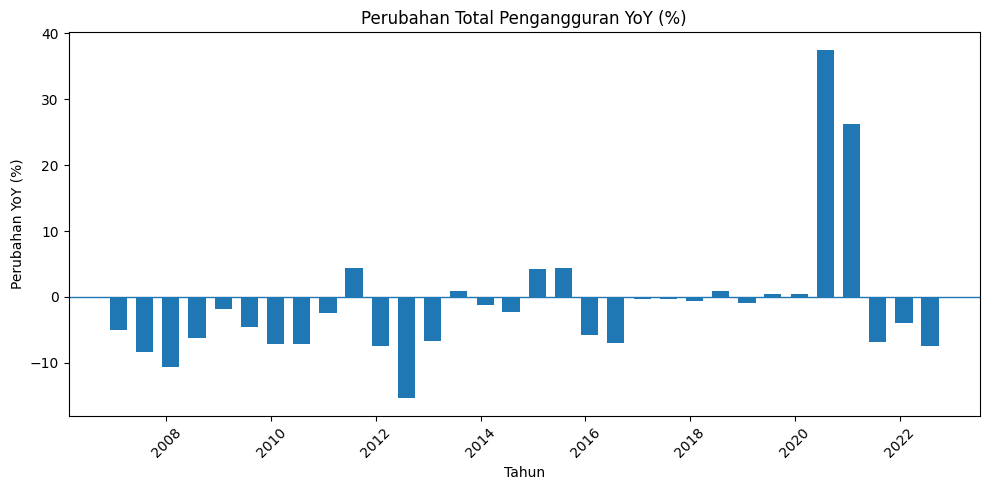

In [ ]:
# Menghitung perubahan year-on-year sederhana
# Karena dataset berisi Februari dan Agustus tiap tahun, shift(2) membandingkan bulan yang sama dengan tahun sebelumnya.
df['Total_tahun_sebelumnya'] = df['Total'].shift(2)
df['Perubahan_YoY'] = df['Total'] - df['Total_tahun_sebelumnya']
df['Perubahan_YoY_%'] = df['Perubahan_YoY'] / df['Total_tahun_sebelumnya'] * 100

display(df[['Tanggal', 'Bulan', 'Periode', 'Total', 'Perubahan_YoY', 'Perubahan_YoY_%']].tail(10))

largest_yoy_increase = df.dropna(subset=['Perubahan_YoY']).loc[df['Perubahan_YoY'].idxmax()]
print(
    f"Kenaikan YoY terbesar terjadi pada {largest_yoy_increase['Bulan']} "
    f"{largest_yoy_increase['Periode']}: naik {largest_yoy_increase['Perubahan_YoY']:,.0f} "
    f"orang atau {largest_yoy_increase['Perubahan_YoY_%']:.2f}% dibanding bulan yang sama tahun sebelumnya."
)

plt.figure()
plt.bar(df['Tanggal'], df['Perubahan_YoY_%'], width=120)
plt.axhline(0, linewidth=1)
plt.title('Perubahan Total Pengangguran YoY (%)')
plt.xlabel('Tahun')
plt.ylabel('Perubahan YoY (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Insight singkat

In [ ]:
# Insight singkat berdasarkan hasil EDA
avg_share = (df[edu_cols].div(df['Total'], axis=0) * 100).mean().sort_values(ascending=False)
latest_top3 = latest_share.head(3)

print("INSIGHT SINGKAT:")
print(f"1. Total pengangguran turun dari {awal['Total']:,.0f} pada {awal['Bulan']} {awal['Periode']} "
      f"menjadi {akhir['Total']:,.0f} pada {akhir['Bulan']} {akhir['Periode']} "
      f"atau turun sekitar {abs(perubahan_pct):.2f}%.")
print(f"2. Total tertinggi ada pada {max_row['Bulan']} {max_row['Periode']} "
      f"sebesar {max_row['Total']:,.0f}, sedangkan total terendah ada pada "
      f"{min_row['Bulan']} {min_row['Periode']} sebesar {min_row['Total']:,.0f}.")
print(f"3. Secara rata-rata, kategori pendidikan dengan kontribusi terbesar adalah "
      f"{avg_share.index[0]} ({avg_share.iloc[0]:.2f}%), diikuti {avg_share.index[1]} "
      f"({avg_share.iloc[1]:.2f}%).")
print(f"4. Pada periode terakhir, tiga kategori terbesar adalah: "
      f"{latest_top3.index[0]} ({latest_top3.iloc[0]:.2f}%), "
      f"{latest_top3.index[1]} ({latest_top3.iloc[1]:.2f}%), dan "
      f"{latest_top3.index[2]} ({latest_top3.iloc[2]:.2f}%).")
print(f"5. Kenaikan YoY terbesar terjadi pada {largest_yoy_increase['Bulan']} "
      f"{largest_yoy_increase['Periode']} dengan kenaikan sekitar "
      f"{largest_yoy_increase['Perubahan_YoY_%']:.2f}%.")
print("6. Dari sisi kualitas data, ditemukan 1 baris duplikat dan 1 baris dengan Total yang tidak sama dengan penjumlahan kategori pendidikan.")


INSIGHT SINGKAT:
1. Total pengangguran turun dari 11,104,693 pada Februari 2006 menjadi 8,425,931 pada Agustus 2022 atau turun sekitar 24.12%.
2. Total tertinggi ada pada Februari 2006 sebesar 11,104,693, sedangkan total terendah ada pada Februari 2019 sebesar 6,898,796.
3. Secara rata-rata, kategori pendidikan dengan kontribusi terbesar adalah SLTA Umum/SMU (26.02%), diikuti SLTP (20.47%).
4. Pada periode terakhir, tiga kategori terbesar adalah: SLTA Umum/SMU (29.41%), SLTA Kejuruan/SMK (19.72%), dan SLTP (17.81%).
5. Kenaikan YoY terbesar terjadi pada Agustus 2020 dengan kenaikan sekitar 37.49%.
6. Dari sisi kualitas data, ditemukan 1 baris duplikat dan 1 baris dengan Total yang tidak sama dengan penjumlahan kategori pendidikan.


## Kesimpulan sementara

Dari EDA awal, dataset menunjukkan bahwa total pengangguran cenderung menurun dari 2006 sampai 2019, lalu terjadi kenaikan besar pada 2020. Berdasarkan kelompok pendidikan, kategori **SLTA Umum/SMU** menjadi kelompok yang paling dominan secara rata-rata maupun pada periode terakhir. Dataset juga perlu sedikit perhatian pada kualitas data karena terdapat satu duplikasi baris dan satu selisih antara kolom `Total` dengan penjumlahan kategori pendidikan.
